In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
# **Add the import statement here:**
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, hamming_loss, cohen_kappa_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.inspection import permutation_importance # Import permutation_importance here

In [ ]:
# **Import numpy**
import numpy as np # This line imports the numpy library and gives it the alias 'np'

In [4]:
# Load data and create combined features (do this ONCE)
excel_data = pd.read_excel('Green_Purchase_Intention_of_Green_Apparel_among_Filipino_Gen_Zs_Scale_1_7.xlsx')
for col_prefix in ['SI', 'EK', 'EC', 'SM', 'PV', 'PQ', 'BC', 'PI']:
    excel_data[f'{col_prefix}_Combined'] = excel_data[[f'{col_prefix}{i}' for i in range(1, 4)]].mean(axis=1)

feature_cols = ['SI_Combined', 'EK_Combined', 'EC_Combined', 'SM_Combined', 'PV_Combined', 'PQ_Combined', 'BC_Combined']
X = excel_data[feature_cols]
y = excel_data['PI_Combined']

In [5]:
# Split data (do this ONCE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
# --- Define Models with Hyperparameter Grids ---
models = {
    "Gradient Boosting": {
        "regressor": GradientBoostingRegressor(),
        "classifier": GradientBoostingClassifier(),
        "regressor_grid": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1]},  # Example grids
        "classifier_grid": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1]}
    },
    "Random Forest": {
        "regressor": RandomForestRegressor(),
        "classifier": RandomForestClassifier(),
        "regressor_grid": {"n_estimators": [50, 100], "max_depth": [None, 10]},
        "classifier_grid": {"n_estimators": [50, 100], "max_depth": [None, 10]}
    },
    "SVM": {
        "regressor": SVR(),
        "classifier": SVC(probability=True),
        "regressor_grid": {"C": [1, 10], "gamma": ["scale", "auto"]},
        "classifier_grid": {"C": [1, 10], "gamma": ["scale", "auto"]}
    },
    "K-Nearest Neighbors": {
        "regressor": KNeighborsRegressor(),
        "classifier": KNeighborsClassifier(),
        "regressor_grid": {"n_neighbors": [3, 5, 7]},
        "classifier_grid": {"n_neighbors": [3, 5, 7]}
    },
    "XGBoost": {
        "regressor": xgb.XGBRegressor(),
        "classifier": xgb.XGBClassifier(),
        "regressor_grid": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1]},
        "classifier_grid": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1]}
    },
    "Decision Tree": {
        "regressor": DecisionTreeRegressor(),
        "classifier": DecisionTreeClassifier(),
        "regressor_grid": {"max_depth": [None, 10], "min_samples_split": [2, 5]},
        "classifier_grid": {"max_depth": [None, 10], "min_samples_split": [2, 5]}
    },
}


Gradient Boosting Regression: R-squared = 0.7116, MSE = 0.3699 (Best params: {'learning_rate': 0.1, 'n_estimators': 50})


<Figure size 1000x800 with 0 Axes>

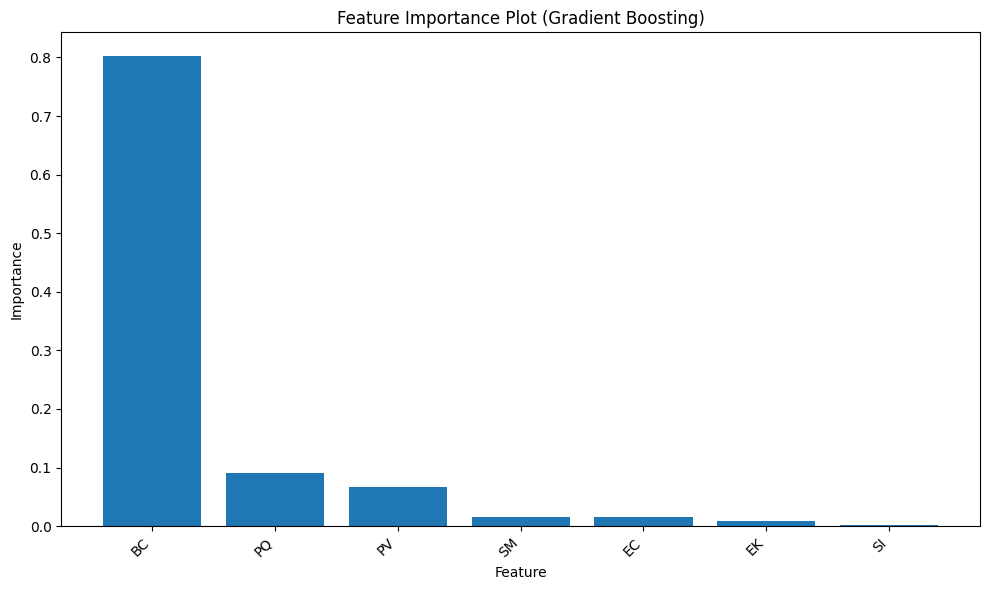

Random Forest Regression: R-squared = 0.7113, MSE = 0.3703 (Best params: {'max_depth': None, 'n_estimators': 50})


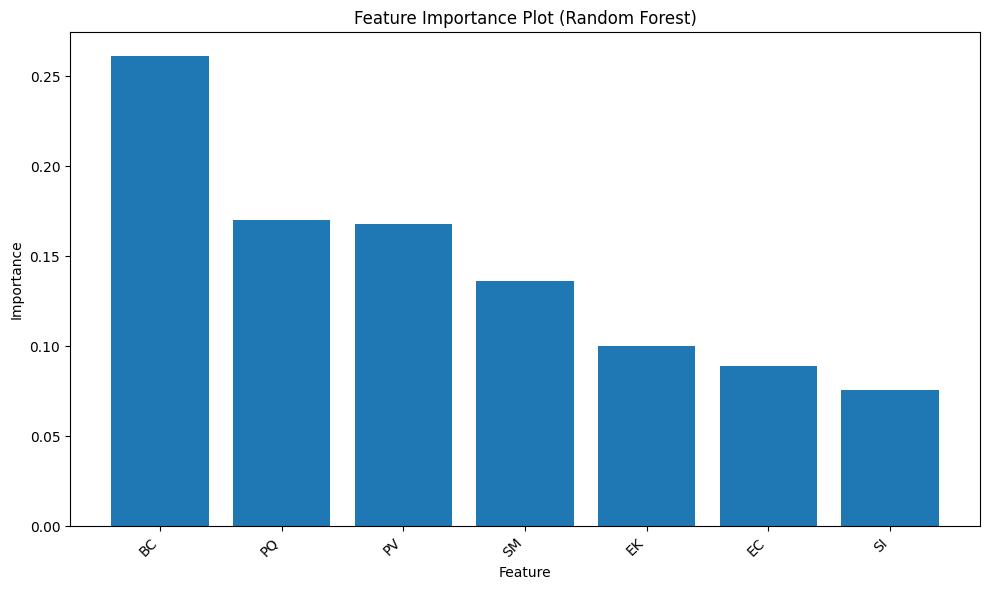

SVM Regression: R-squared = 0.6857, MSE = 0.4032 (Best params: {'C': 1, 'gamma': 'auto'})


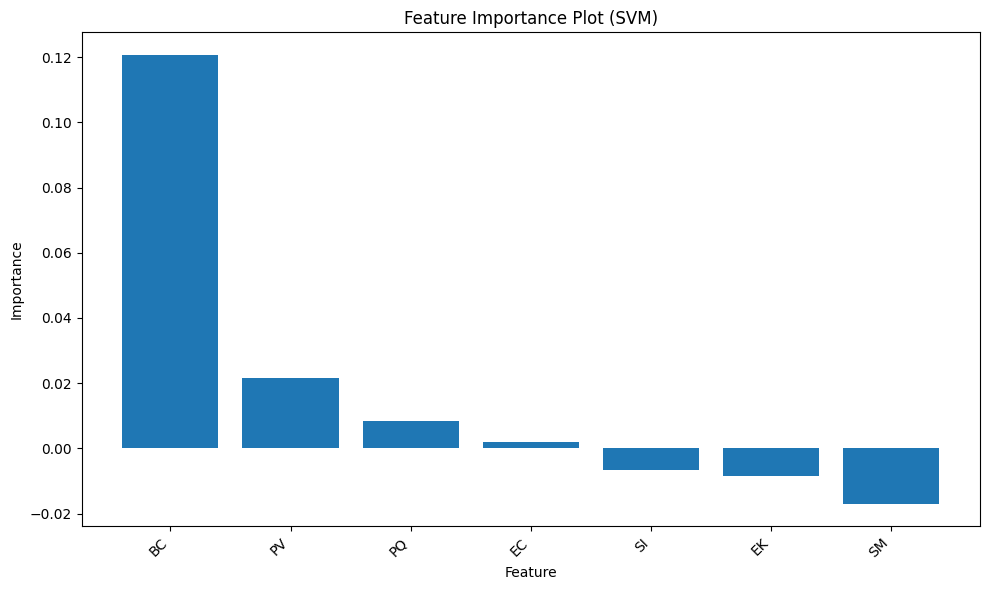

K-Nearest Neighbors Regression: R-squared = 0.7418, MSE = 0.3312 (Best params: {'n_neighbors': 7})


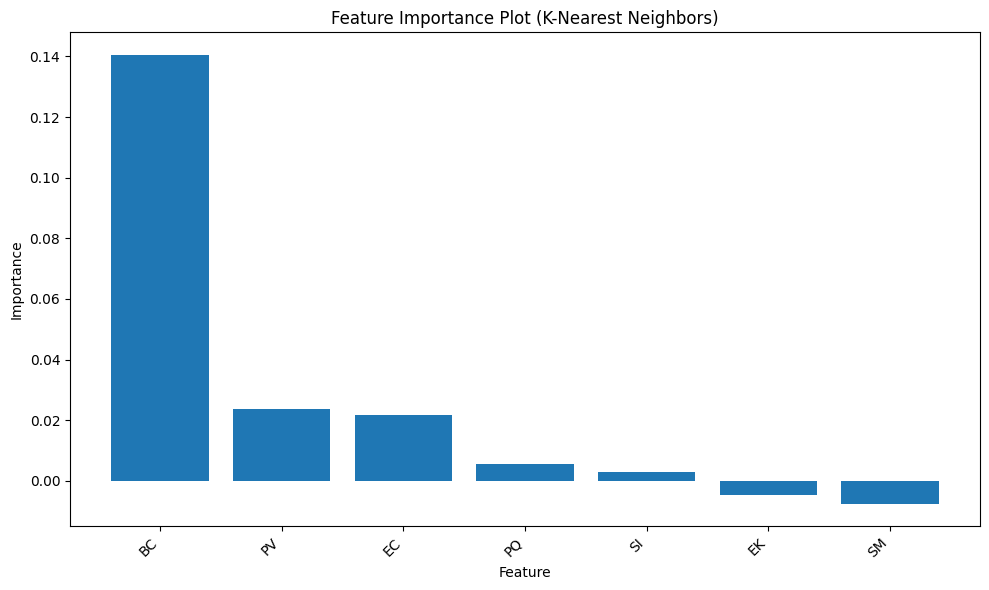

XGBoost Regression: R-squared = 0.6670, MSE = 0.4271 (Best params: {'learning_rate': 0.1, 'n_estimators': 50})


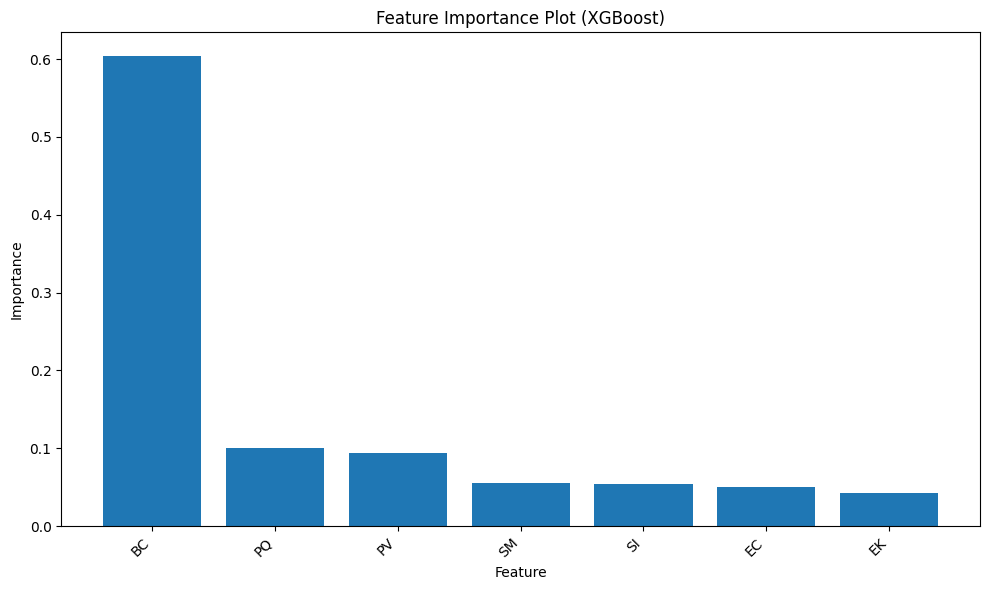

Decision Tree Regression: R-squared = 0.5029, MSE = 0.6376 (Best params: {'max_depth': 10, 'min_samples_split': 2})


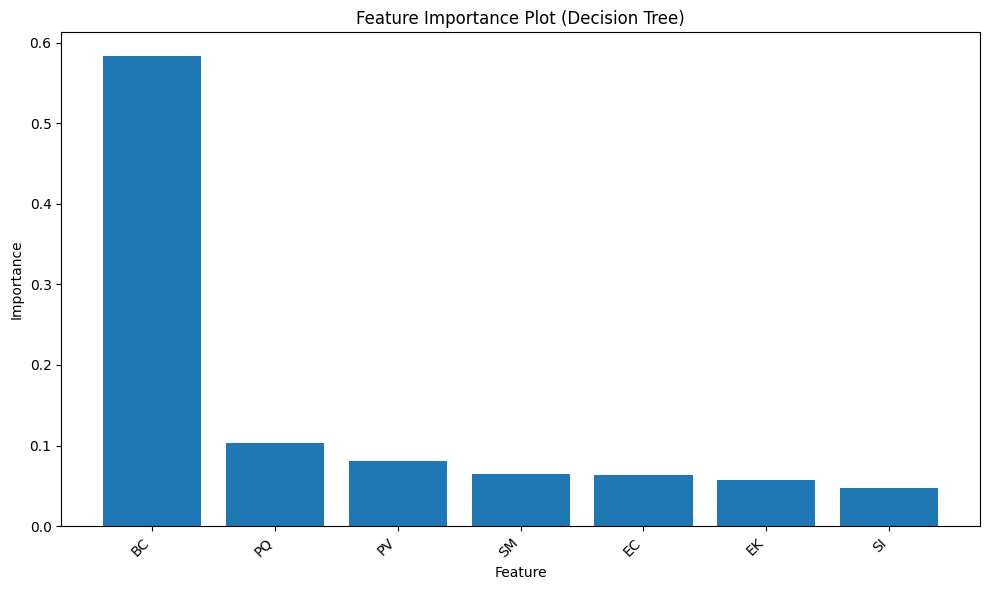

Classification Metrics for Gradient Boosting:
  Accuracy: 0.8774
  Precision: 0.8730
  Recall: 0.9167
  F1-score: 0.8943
  Hamming Loss: 0.1226
  Kappa Score: 0.7484
  ROC AUC Score: 0.9493
  best_classifier: GradientBoostingClassifier(learning_rate=0.01)
------------------------------
Classification Metrics for Random Forest:
  Accuracy: 0.8679
  Precision: 0.8966
  Recall: 0.8667
  F1-score: 0.8814
  Hamming Loss: 0.1321
  Kappa Score: 0.7325
  ROC AUC Score: 0.9520
  best_classifier: RandomForestClassifier(max_depth=10, n_estimators=50)
------------------------------
Classification Metrics for SVM:
  Accuracy: 0.8585
  Precision: 0.8689
  Recall: 0.8833
  F1-score: 0.8760
  Hamming Loss: 0.1415
  Kappa Score: 0.7112
  ROC AUC Score: 0.9489
  best_classifier: SVC(C=1, gamma='auto', probability=True)
------------------------------
Classification Metrics for K-Nearest Neighbors:
  Accuracy: 0.8774
  Precision: 0.8983
  Recall: 0.8833
  F1-score: 0.8908
  Hamming Loss: 0.1226
  Kappa Sc

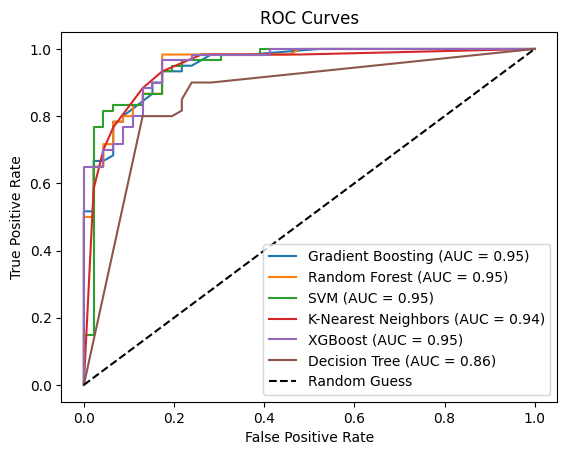

In [ ]:
# --- Train and Evaluate with GridSearchCV ---
results = {}
classification_results = {}  # Initialize classification_results
plt.figure(figsize=(10, 8))  # Initialize the figure outside the loop

for name, model_dict in models.items():
    # Regression
    regressor = model_dict["regressor"]
    regressor_grid = model_dict["regressor_grid"]

    grid_search_reg = GridSearchCV(regressor, regressor_grid, cv=3, scoring='r2') # cv for cross-validation
    grid_search_reg.fit(X_train, y_train)
    best_regressor = grid_search_reg.best_estimator_

    y_pred_reg = best_regressor.predict(X_test)
    r2 = r2_score(y_test, y_pred_reg)
    mse = mean_squared_error(y_test, y_pred_reg)
    results[name] = {"r2": r2, "mse": mse}
    print(f"{name} Regression: R-squared = {r2:.4f}, MSE = {mse:.4f} (Best params: {grid_search_reg.best_params_})")

       # Classification
    threshold = y_train.mean()
    classifier = model_dict["classifier"]
    classifier_grid = model_dict["classifier_grid"]

    y_train_binary = (y_train > threshold).astype(int)
    y_test_binary = (y_test > threshold).astype(int)

    grid_search_class = GridSearchCV(classifier, classifier_grid, cv=3, scoring='roc_auc') # Use appropriate scoring
    grid_search_class.fit(X_train, y_train_binary)
    best_classifier = grid_search_class.best_estimator_

    y_pred_class = best_classifier.predict(X_test)
    y_pred_proba = best_classifier.predict_proba(X_test)[:, 1]  # Get probabilities for ROC AUC

    # Feature Importance Plotting (For all Classifiers including KNN and SVM)
    if name in ["K-Nearest Neighbors", "SVM"]:  # Permutation importance for KNN and SVM
        result = permutation_importance(best_classifier, X_test, y_test_binary, n_repeats=10, random_state=1)
        importances = result.importances_mean
    elif hasattr(best_classifier, 'feature_importances_'):  # Built-in importance for others
        importances = best_classifier.feature_importances_
    else:
        print(f"{name} Classifier does not have feature_importances_ attribute.")
        continue  # Skip plotting for models without importance

    # Sort features and create DataFrame (common for all models)
    indices = np.argsort(importances)[::-1]
    feature_importance_df = pd.DataFrame({
        'Feature': [feature_cols[i].replace('_Combined', '') for i in indices],
        'Importance': importances[indices]
    })

    # Plot feature importances
    plt.figure(figsize=(10, 6))
    plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.xlabel('Feature')
    plt.ylabel('Importance')
    plt.title(f'Feature Importance Plot ({name})')  # Simplified title
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Calculate and store classification metrics
    # Store the best_classifier object:
    classification_results[name] = {
        'Accuracy': accuracy_score(y_test_binary, y_pred_class),
        'Precision': precision_score(y_test_binary, y_pred_class),
        'Recall': recall_score(y_test_binary, y_pred_class),
        'F1-score': f1_score(y_test_binary, y_pred_class),
        'Hamming Loss': hamming_loss(y_test_binary, y_pred_class),
        'Kappa Score': cohen_kappa_score(y_test_binary, y_pred_class),
        'ROC AUC Score': roc_auc_score(y_test_binary, y_pred_proba), # Calculate ROC AUC here
        'best_classifier': best_classifier  # Store the classifier
    }

# Print classification results
for name, metrics in classification_results.items():
    print(f"Classification Metrics for {name}:")
    for metric, value in metrics.items():
        if metric == 'best_classifier':  # Check if the metric is 'best_classifier'
            print(f"  {metric}: {value}")  # Print without formatting
        else:
            print(f"  {metric}: {value:.4f}")  # Print with formatting
    print("-" * 30)

# Plot ROC curves for all models
for name, result_dict in classification_results.items():
    best_classifier = result_dict['best_classifier']  # Retrieve the classifier
    y_pred_proba = best_classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba)
    roc_auc = roc_auc_score(y_test_binary, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plotting elements (Outside the loop)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.show()